In [1]:
from sklearn.tree import ExtraTreeClassifier
from scipy.stats import randint, uniform
import sys
from pathlib import Path

import numpy as np

# Go up one level to project root
project_root = Path.cwd().parent.parent
sys.path.insert(0, str(project_root))

from src.utils.tune_hyperparameters import ModelTuner, PipelineTuner
filename = r"../../data/raw/ACME-HappinessSurvey2020.csv"

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import StratifiedKFold, StratifiedGroupKFold, RepeatedStratifiedKFold, RepeatedKFold


# model
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
import xgboost as xgb
xgb.set_config(verbosity=2)

e:\dev\workspace\Apziva\Project1\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import sys
from pathlib import Path

# Go up one level to project root
project_root = Path.cwd().parent.parent
sys.path.insert(0, str(project_root))

filename = r"../../data/raw/ACME-HappinessSurvey2020.csv"

In [3]:
random_state = 0

___

# Hyperparameter Tuning

___

Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV 1/5; 1/100] START learning_rate=0.17464405117819742, max_depth=3, n_estimators=5, tree_method=hist
[21:35:20] ======== Monitor (0): HostSketchContainer ========
[21:35:20] AllReduce: 5.4e-05s, 1 calls @ 54us

[21:35:20] MakeCuts: 6.8e-05s, 1 calls @ 68us

[21:35:20] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (80, 6, 480).
[21:35:20] DEBUG: C:\actions-runner\_work\xgboost\xgboost\src\gbm\gbtree.cc:126: Using tree method: 3
[21:35:20] ======== Monitor (0): GBTree ========
[21:35:20] BoostNewTrees: 0.000933s, 5 calls @ 933us

[21:35:20] CommitModel: 9e-06s, 5 calls @ 9us

[21:35:20] ======== Monitor (0): HistUpdater ========
[21:35:20] BuildHistogram: 0.000181s, 10 calls @ 181us

[21:35:20] EvaluateSplits: 0.00017s, 15 calls @ 170us

[21:35:20] InitData: 7.9e-05s, 5 calls @ 79us

[21:35:20] InitRoot: 0.000184s, 5 calls @ 184us

[21:35:20] Le

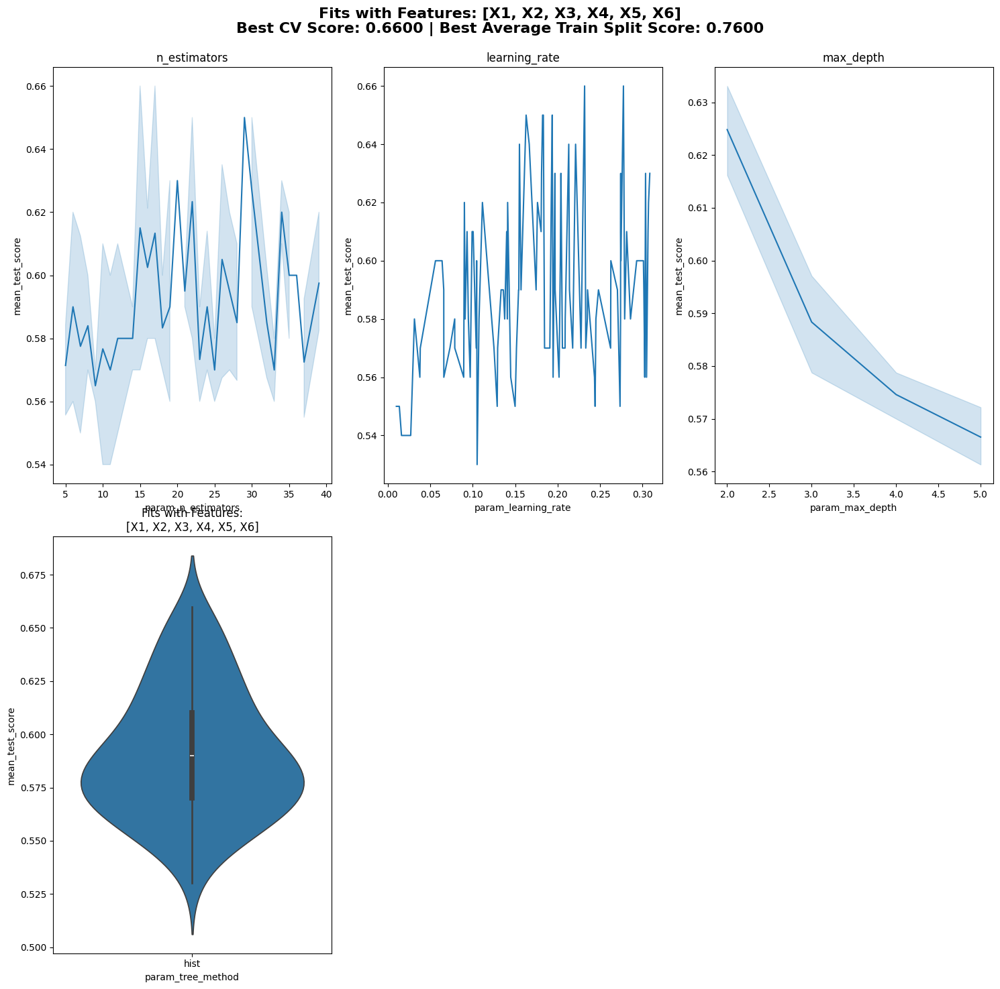

[21:35:37] ======== Monitor (0): HostSketchContainer ========
[21:35:37] AllReduce: 4.8e-05s, 1 calls @ 48us

[21:35:37] MakeCuts: 5.9e-05s, 1 calls @ 59us

[21:35:37] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (100, 6, 600).
[21:35:37] DEBUG: C:\actions-runner\_work\xgboost\xgboost\src\gbm\gbtree.cc:126: Using tree method: 3
[21:35:37] ======== Monitor (0): GBTree ========
[21:35:37] BoostNewTrees: 0.002529s, 17 calls @ 2529us

[21:35:37] CommitModel: 1.2e-05s, 17 calls @ 12us

[21:35:37] ======== Monitor (0): HistUpdater ========
[21:35:37] BuildHistogram: 0.000358s, 17 calls @ 358us

[21:35:37] EvaluateSplits: 0.000466s, 34 calls @ 466us

[21:35:37] InitData: 0.000201s, 17 calls @ 201us

[21:35:37] InitRoot: 0.000635s, 17 calls @ 635us

[21:35:37] LeafPartition: 0.000105s, 17 calls @ 105us

[21:35:37] UpdatePosition: 0.000469s, 34 calls @ 469us

[21:35:37] UpdatePredictionCache: 9.7e-05s, 17 calls @ 9

e:\dev\workspace\Apziva\Project1\src\utils\tune_hyperparameters.py:297: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_subset, show=False)


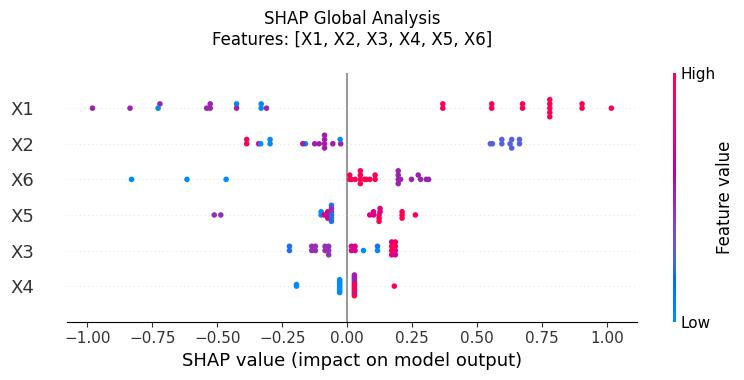

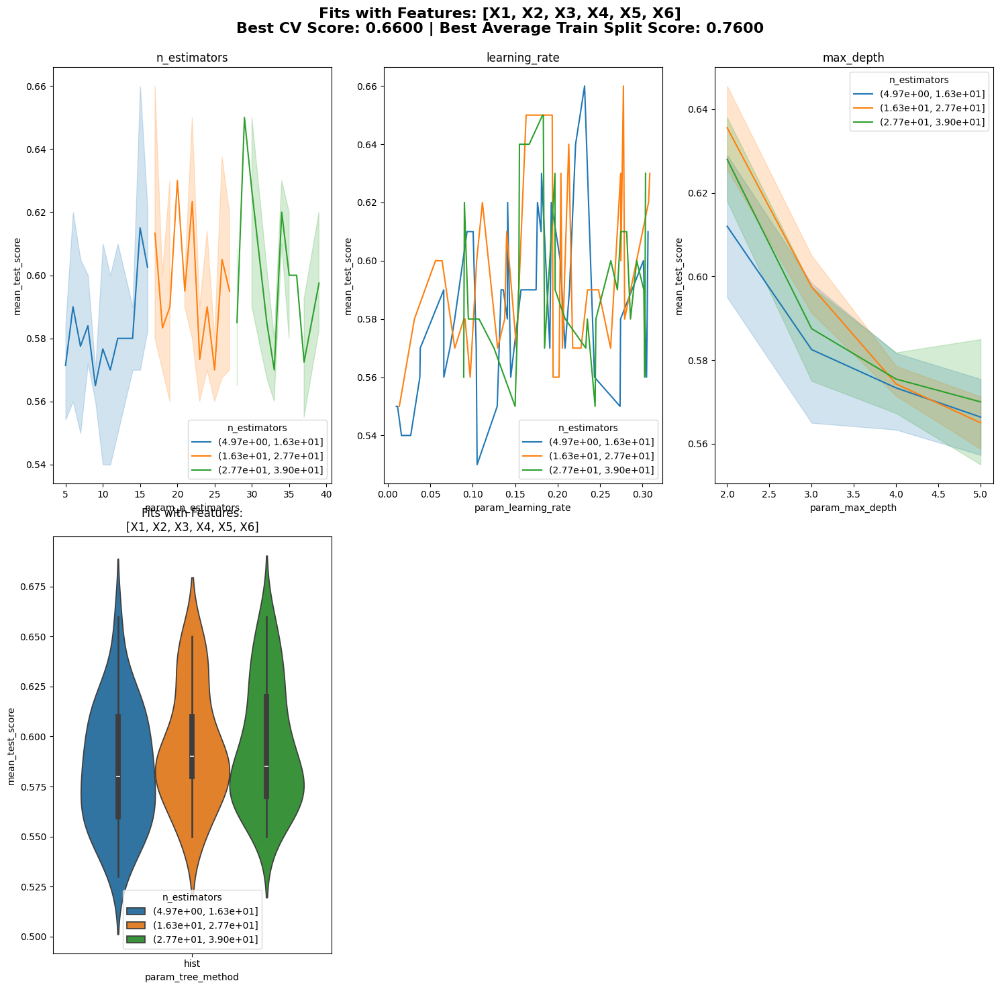

In [4]:
parameter_grid = {
        # Number of boosted trees to fit (also equivalent to number of boosting rounds)
        'n_estimators': randint(5, 40),

        # Step size shrinkage used in updates to prevent overfitting
        'learning_rate': uniform(0.01, .3),

        # Maximum depth of a tree. Increasing this makes the model more complex and likely to overfit
        'max_depth': randint(2,6),

        # Minimum sum of instance weight (hessian) needed in a child
        # 'min_child_weight': uniform(1, 5),

        # Subsample ratio of the training instances (fraction of observations used per tree)
        # 'subsample': [.5,.6,.7,.8,.9,1],

        # Subsample ratio of columns when constructing each tree
        # 'colsample_bytree': [.5,.75,1],

        # Minimum loss reduction required to make a further partition on a leaf node
        # 'gamma': uniform(0, 4),

        # L1 regularization term on weights (higher values make the model more conservative)
        # 'reg_alpha':uniform(0,1),

        # L2 regularization term on weights (higher values make the model more conservative)
        # 'reg_lambda': randint(1, 15),

        # Maximum number of discrete bins to bucket continuous features
        # 'max_bin': randint(64, 256),

        # Specifies the tree construction algorithm used
        'tree_method': ['hist'],

        # Specifies the type of booster to use
        # 'booster': ['gbtree',]
}
model = xgb.XGBClassifier(random_state = random_state, verbosity = 3,)
categorical_features = ["X1","X2","X3","X4","X5","X6"]

t = ModelTuner(model, filename, "Y", categorical_features, random_state = random_state)

search = t.tune_model(hyperParameterGrid=parameter_grid, n_iter = 100,)
t.feature_permutation(search.best_params_)
t.shap_analysis(search.best_params_)
t.display_parameter_fits(search, parameter_grid, groupby="n_estimators")

Fitting 5 folds for each of 500 candidates, totalling 2500 fits
[CV 1/5; 1/500] START learning_rate=0.17464405117819742, max_depth=3, n_estimators=5, tree_method=hist
[21:35:39] ======== Monitor (0): HostSketchContainer ========
[21:35:39] AllReduce: 1.7e-05s, 1 calls @ 17us

[21:35:39] MakeCuts: 2.1e-05s, 1 calls @ 21us

[21:35:39] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (80, 4, 320).
[21:35:39] DEBUG: C:\actions-runner\_work\xgboost\xgboost\src\gbm\gbtree.cc:126: Using tree method: 3
[21:35:39] ======== Monitor (0): GBTree ========
[21:35:39] BoostNewTrees: 0.001255s, 5 calls @ 1255us

[21:35:39] CommitModel: 4e-06s, 5 calls @ 4us

[21:35:39] ======== Monitor (0): HistUpdater ========
[21:35:39] BuildHistogram: 0.000336s, 10 calls @ 336us

[21:35:39] EvaluateSplits: 0.000237s, 15 calls @ 237us

[21:35:39] InitData: 6.6e-05s, 5 calls @ 66us

[21:35:39] InitRoot: 0.000256s, 5 calls @ 256us

[21:35:39]

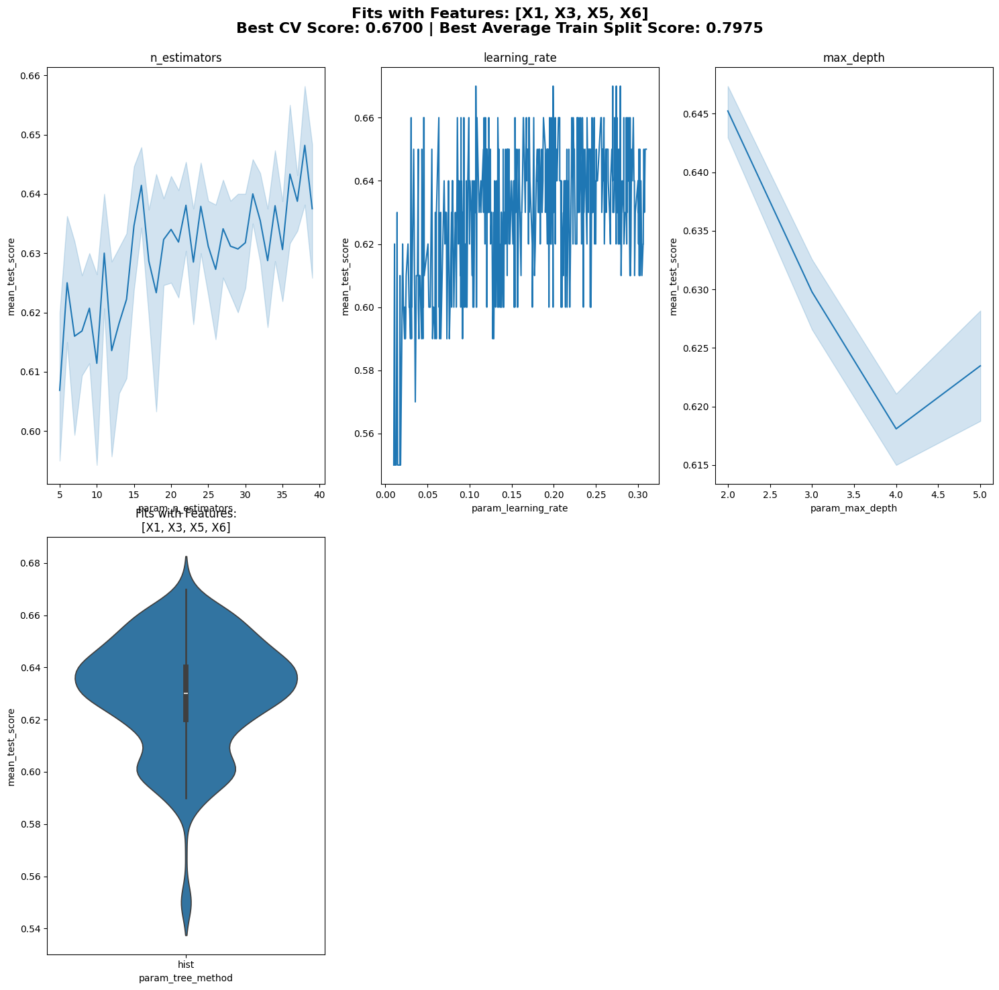

[21:36:53] ======== Monitor (0): HostSketchContainer ========
[21:36:53] AllReduce: 2.1e-05s, 1 calls @ 21us

[21:36:53] MakeCuts: 2.6e-05s, 1 calls @ 26us

[21:36:53] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (100, 4, 400).
[21:36:53] DEBUG: C:\actions-runner\_work\xgboost\xgboost\src\gbm\gbtree.cc:126: Using tree method: 3
[21:36:53] ======== Monitor (0): GBTree ========
[21:36:53] BoostNewTrees: 0.027012s, 38 calls @ 27012us

[21:36:53] CommitModel: 2.5e-05s, 38 calls @ 25us

[21:36:53] ======== Monitor (0): HistUpdater ========
[21:36:53] BuildHistogram: 0.005766s, 152 calls @ 5766us

[21:36:53] EvaluateSplits: 0.010772s, 190 calls @ 10772us

[21:36:53] InitData: 0.000539s, 38 calls @ 539us

[21:36:53] InitRoot: 0.001749s, 38 calls @ 1749us

[21:36:53] LeafPartition: 0.000346s, 38 calls @ 346us

[21:36:53] UpdatePosition: 0.005891s, 187 calls @ 5891us

[21:36:53] UpdatePredictionCache: 0.000317s, 38

e:\dev\workspace\Apziva\Project1\src\utils\tune_hyperparameters.py:297: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_subset, show=False)


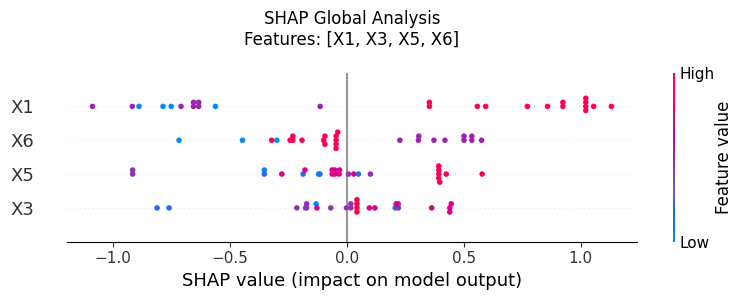

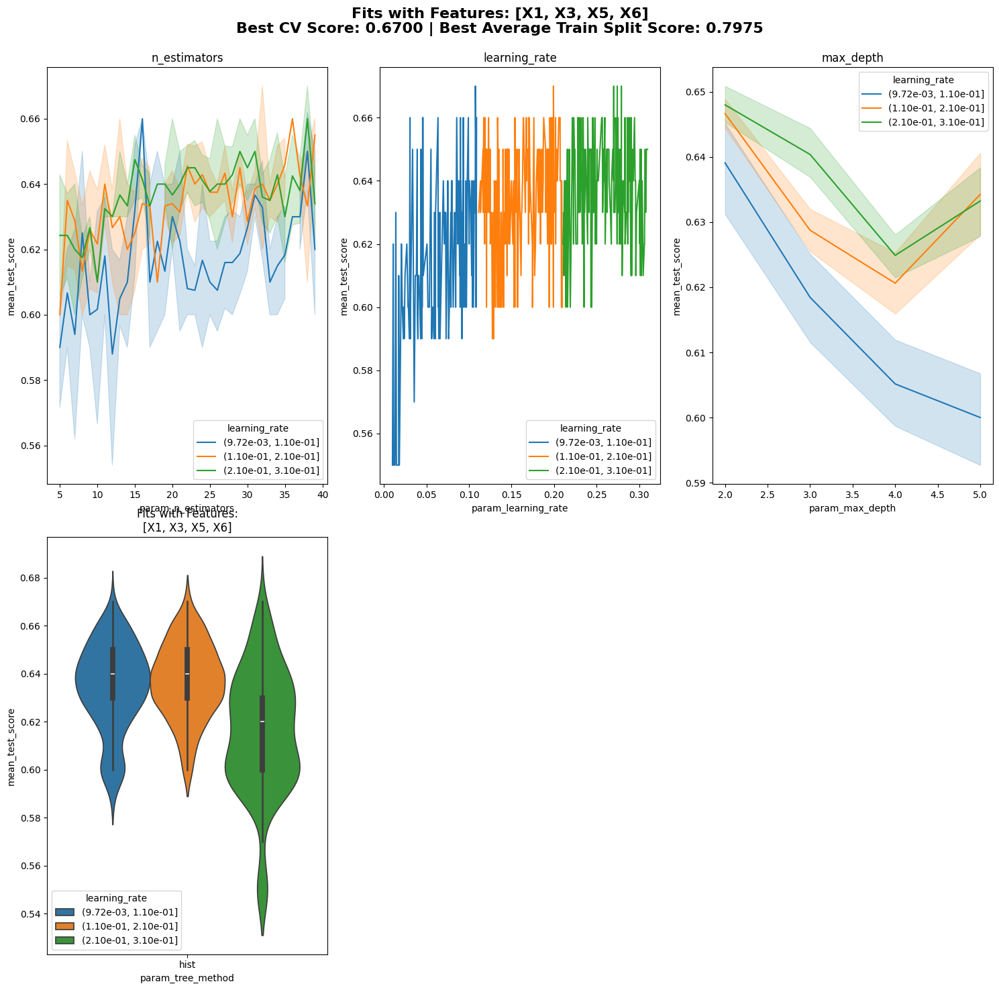

In [5]:
# features based on correlation found in exploratory notebook
t.set_features(["X1","X3","X5","X6"])

search = t.tune_model(hyperParameterGrid=parameter_grid, n_iter = 500,)
t.feature_permutation(search.best_params_)
t.shap_analysis(search.best_params_)
t.display_parameter_fits(search, parameter_grid, groupby="learning_rate")

Fitting 5 folds for each of 500 candidates, totalling 2500 fits
[CV 1/5; 1/500] START learning_rate=0.17464405117819742, max_depth=3, n_estimators=5, tree_method=hist
[21:36:56] ======== Monitor (0): HostSketchContainer ========
[21:36:56] AllReduce: 1.3e-05s, 1 calls @ 13us

[21:36:56] MakeCuts: 1.7e-05s, 1 calls @ 17us

[21:36:56] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (80, 3, 240).
[21:36:56] DEBUG: C:\actions-runner\_work\xgboost\xgboost\src\gbm\gbtree.cc:126: Using tree method: 3
[21:36:56] ======== Monitor (0): GBTree ========
[21:36:56] BoostNewTrees: 0.00059s, 5 calls @ 590us

[21:36:56] CommitModel: 5e-06s, 5 calls @ 5us

[21:36:56] ======== Monitor (0): HistUpdater ========
[21:36:56] BuildHistogram: 0.000118s, 10 calls @ 118us

[21:36:56] EvaluateSplits: 0.000116s, 15 calls @ 116us

[21:36:56] InitData: 3.7e-05s, 5 calls @ 37us

[21:36:56] InitRoot: 0.000101s, 5 calls @ 101us

[21:36:56] L

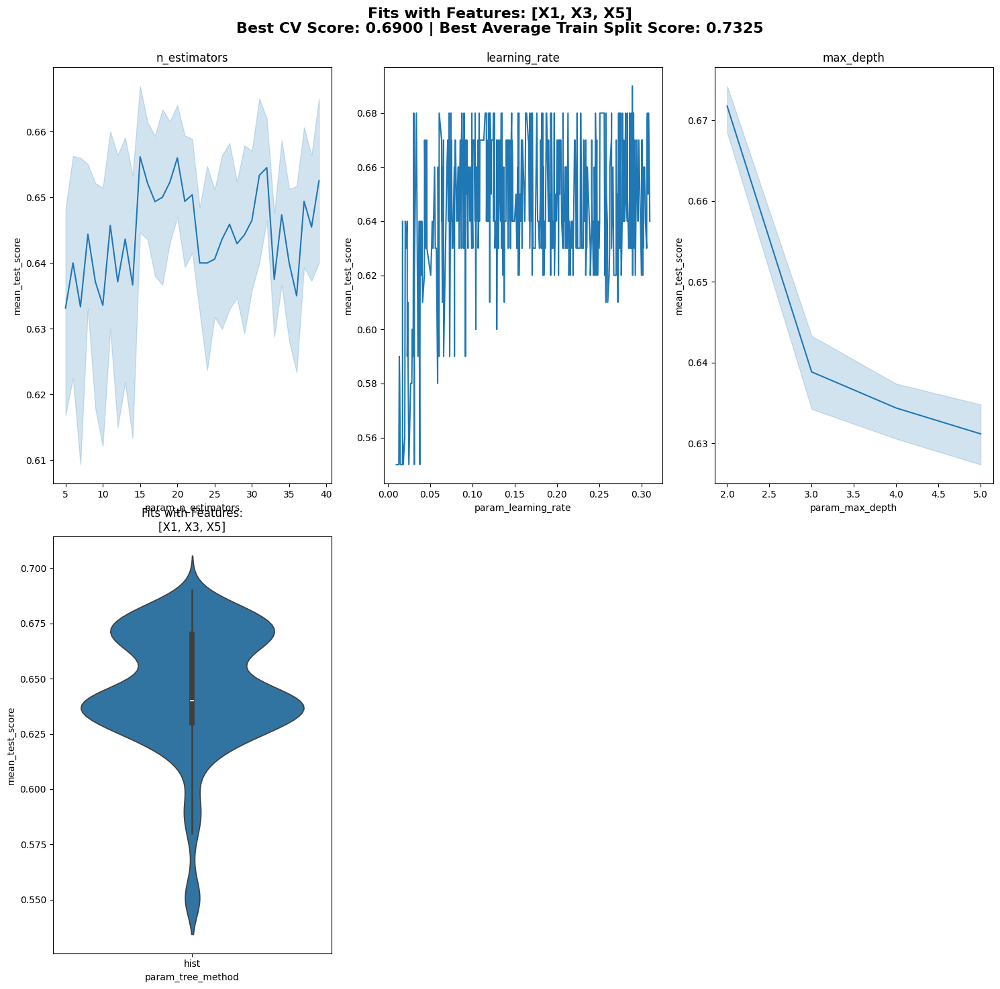

[21:38:06] ======== Monitor (0): HostSketchContainer ========
[21:38:06] AllReduce: 1.2e-05s, 1 calls @ 12us

[21:38:06] MakeCuts: 1.6e-05s, 1 calls @ 16us

[21:38:06] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (100, 3, 300).
[21:38:06] DEBUG: C:\actions-runner\_work\xgboost\xgboost\src\gbm\gbtree.cc:126: Using tree method: 3
[21:38:06] ======== Monitor (0): GBTree ========
[21:38:06] BoostNewTrees: 0.002497s, 25 calls @ 2497us

[21:38:06] CommitModel: 1.5e-05s, 25 calls @ 15us

[21:38:06] ======== Monitor (0): HistUpdater ========
[21:38:06] BuildHistogram: 0.000318s, 25 calls @ 318us

[21:38:06] EvaluateSplits: 0.000377s, 50 calls @ 377us

[21:38:06] InitData: 0.000243s, 25 calls @ 243us

[21:38:06] InitRoot: 0.000619s, 25 calls @ 619us

[21:38:06] LeafPartition: 9e-05s, 25 calls @ 90us

[21:38:06] UpdatePosition: 0.000403s, 50 calls @ 403us

[21:38:06] UpdatePredictionCache: 8.2e-05s, 25 calls @ 82us


e:\dev\workspace\Apziva\Project1\src\utils\tune_hyperparameters.py:297: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_subset, show=False)


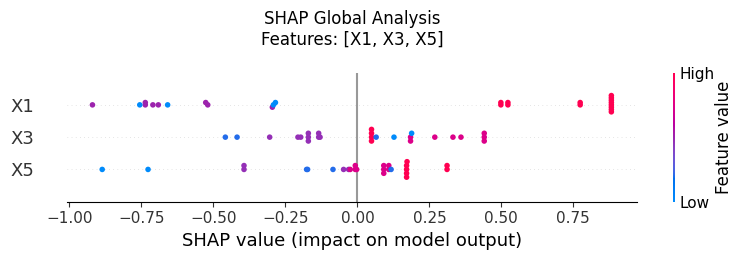

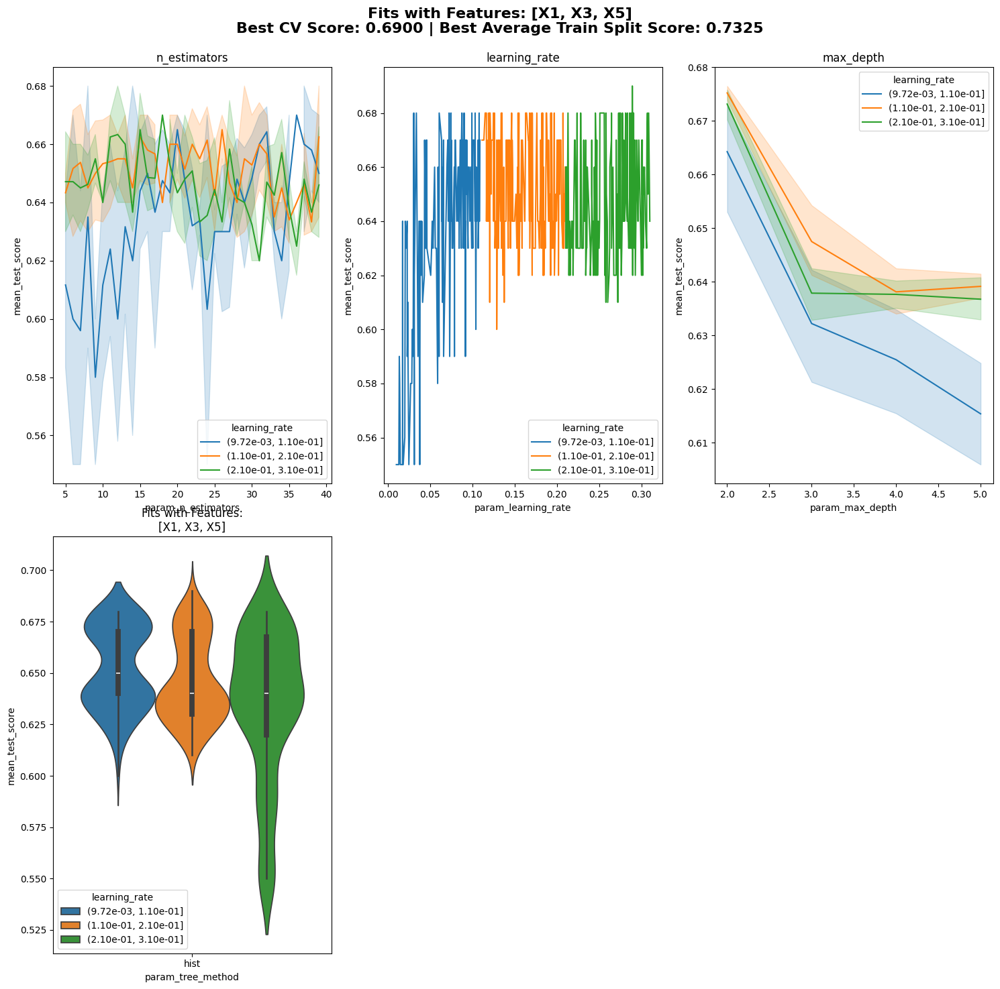

In [6]:
# features based on correlation found in exploratory notebook
t.set_features(["X1","X3","X5"])

search = t.tune_model(hyperParameterGrid=parameter_grid, n_iter = 500,)
t.feature_permutation(search.best_params_)
t.shap_analysis(search.best_params_)
t.display_parameter_fits(search, parameter_grid, groupby="learning_rate")

In [7]:
t.last_search.best_params_

{'learning_rate': np.float64(0.2892518363344007),
 'max_depth': 2,
 'n_estimators': 25,
 'tree_method': 'hist'}

Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV 1/5; 1/100] START learning_rate=0.2892518363344007, max_depth=2, n_estimators=25, reg_lambda=6, subsample=0.7, tree_method=hist
[21:38:09] ======== Monitor (0): HostSketchContainer ========
[21:38:09] AllReduce: 1.5e-05s, 1 calls @ 15us

[21:38:09] MakeCuts: 1.9e-05s, 1 calls @ 19us

[21:38:09] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (80, 3, 240).
[21:38:09] DEBUG: C:\actions-runner\_work\xgboost\xgboost\src\gbm\gbtree.cc:126: Using tree method: 3
[21:38:09] ======== Monitor (0): GBTree ========
[21:38:09] BoostNewTrees: 0.003202s, 25 calls @ 3202us

[21:38:09] CommitModel: 1.8e-05s, 25 calls @ 18us

[21:38:09] ======== Monitor (0): HistUpdater ========
[21:38:09] BuildHistogram: 0.000448s, 25 calls @ 448us

[21:38:09] EvaluateSplits: 0.000598s, 50 calls @ 598us

[21:38:09] InitData: 0.000212s, 25 calls @ 212us

[21:38:09] InitRoot: 0.

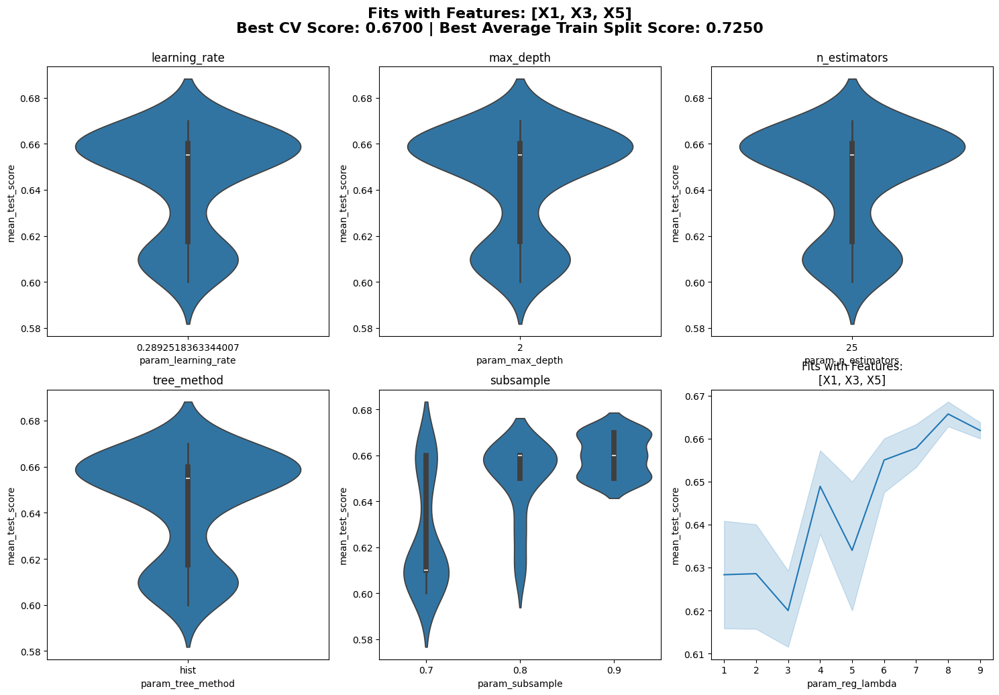

[21:38:24] ======== Monitor (0): HostSketchContainer ========
[21:38:24] AllReduce: 2.2e-05s, 1 calls @ 22us

[21:38:24] MakeCuts: 2.8e-05s, 1 calls @ 28us

[21:38:24] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (100, 3, 300).
[21:38:24] DEBUG: C:\actions-runner\_work\xgboost\xgboost\src\gbm\gbtree.cc:126: Using tree method: 3
[21:38:24] ======== Monitor (0): GBTree ========
[21:38:24] BoostNewTrees: 0.003392s, 25 calls @ 3392us

[21:38:24] CommitModel: 1.5e-05s, 25 calls @ 15us

[21:38:24] ======== Monitor (0): HistUpdater ========
[21:38:24] BuildHistogram: 0.000813s, 25 calls @ 813us

[21:38:24] EvaluateSplits: 0.000467s, 50 calls @ 467us

[21:38:24] InitData: 0.000212s, 25 calls @ 212us

[21:38:24] InitRoot: 0.000672s, 25 calls @ 672us

[21:38:24] LeafPartition: 0.000128s, 25 calls @ 128us

[21:38:24] UpdatePosition: 0.000577s, 50 calls @ 577us

[21:38:24] UpdatePredictionCache: 0.000139s, 25 calls @ 

e:\dev\workspace\Apziva\Project1\src\utils\tune_hyperparameters.py:297: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_subset, show=False)


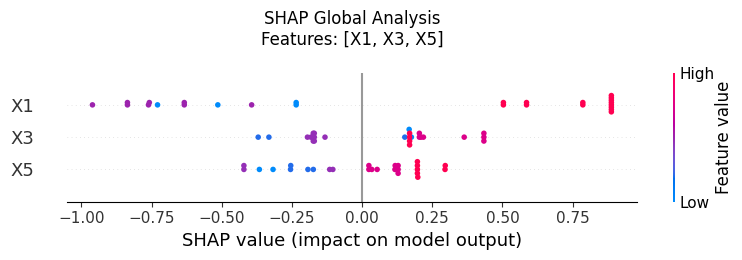

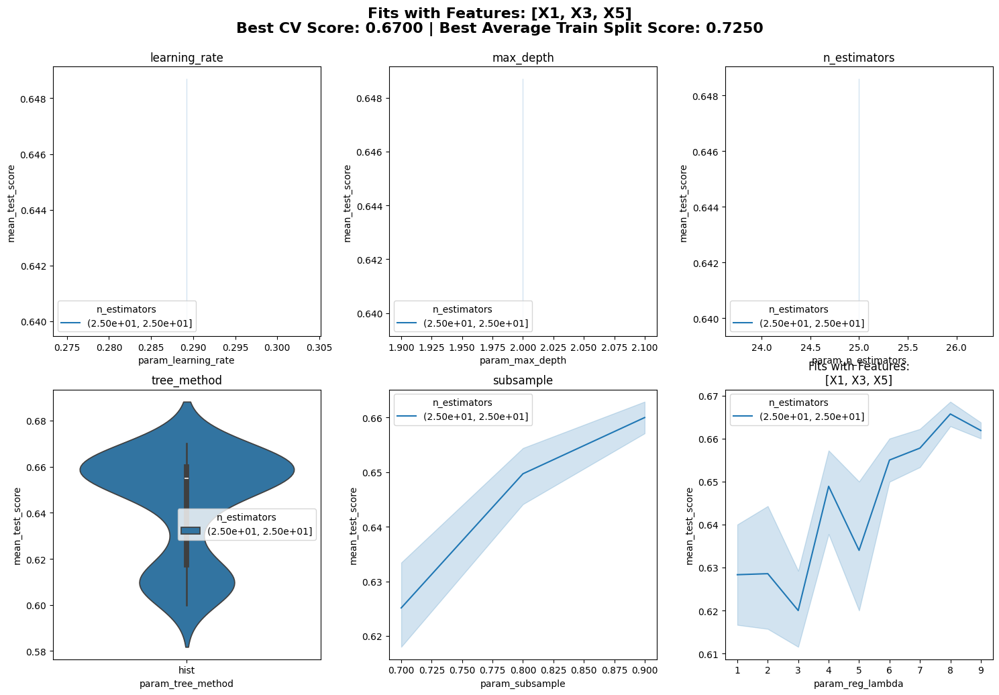

In [8]:
parameter_grid = {

        'learning_rate': [np.float64(0.2892518363344007)],
        'max_depth': [2],
        'n_estimators': [25],
        'tree_method': ['hist'],

        # Minimum sum of instance weight (hessian) needed in a child
        # 'min_child_weight': uniform(1, 5),

        # Subsample ratio of the training instances (fraction of observations used per tree)
        'subsample': [.7,.8,.9],

        # Subsample ratio of columns when constructing each tree
        # 'colsample_bytree': [.5,.75,1],

        # Minimum loss reduction required to make a further partition on a leaf node
        # 'gamma': uniform(0, 4),

        # L1 regularization term on weights (higher values make the model more conservative)
        # 'reg_alpha':uniform(0,1),

        # L2 regularization term on weights (higher values make the model more conservative)
        'reg_lambda': randint(1, 10),

        # Maximum number of discrete bins to bucket continuous features
        # 'max_bin': randint(64, 256),

        # Specifies the type of booster to use
        # 'booster': ['gbtree',]

}

search = t.tune_model(hyperParameterGrid=parameter_grid, n_iter = 100,)
t.feature_permutation(search.best_params_)
t.shap_analysis(search.best_params_)
t.display_parameter_fits(search, parameter_grid, groupby="n_estimators")

In [9]:
search.best_params_

{'learning_rate': np.float64(0.2892518363344007),
 'max_depth': 2,
 'n_estimators': 25,
 'reg_lambda': 8,
 'subsample': 0.9,
 'tree_method': 'hist'}

In [10]:
t.predict_test_split(t.last_search.best_params_)

[21:38:25] ======== Monitor (0): HostSketchContainer ========
[21:38:25] AllReduce: 0.000323s, 1 calls @ 323us

[21:38:25] MakeCuts: 0.000329s, 1 calls @ 329us

[21:38:25] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (100, 3, 300).
[21:38:25] DEBUG: C:\actions-runner\_work\xgboost\xgboost\src\gbm\gbtree.cc:126: Using tree method: 3
[21:38:25] ======== Monitor (0): GBTree ========
[21:38:25] BoostNewTrees: 0.003546s, 25 calls @ 3546us

[21:38:25] CommitModel: 1.6e-05s, 25 calls @ 16us

[21:38:25] ======== Monitor (0): HistUpdater ========
[21:38:25] BuildHistogram: 0.000522s, 25 calls @ 522us

[21:38:25] EvaluateSplits: 0.000546s, 50 calls @ 546us

[21:38:25] InitData: 0.00025s, 25 calls @ 250us

[21:38:25] InitRoot: 0.00089s, 25 calls @ 890us

[21:38:25] LeafPartition: 0.000173s, 25 calls @ 173us

[21:38:25] UpdatePosition: 0.000615s, 50 calls @ 615us

[21:38:25] UpdatePredictionCache: 0.000133s, 25 calls 

0.5384615384615384

# Overfit to the cv score

In [11]:
random_state += 1

Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV 1/5; 1/100] START learning_rate=0.13510660141077221, max_depth=2, n_estimators=13, reg_lambda=19, subsample=0.8, tree_method=hist
[21:38:25] ======== Monitor (0): HostSketchContainer ========
[21:38:25] AllReduce: 3.8e-05s, 1 calls @ 38us

[21:38:25] MakeCuts: 4.5e-05s, 1 calls @ 45us

[21:38:25] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (80, 6, 480).
[21:38:25] DEBUG: C:\actions-runner\_work\xgboost\xgboost\src\gbm\gbtree.cc:126: Using tree method: 3
[21:38:25] ======== Monitor (0): GBTree ========
[21:38:25] BoostNewTrees: 0.002327s, 13 calls @ 2327us

[21:38:25] CommitModel: 1.1e-05s, 13 calls @ 11us

[21:38:25] ======== Monitor (0): HistUpdater ========
[21:38:25] BuildHistogram: 0.000323s, 13 calls @ 323us

[21:38:25] EvaluateSplits: 0.000344s, 26 calls @ 344us

[21:38:25] InitData: 0.000166s, 13 calls @ 166us

[21:38:25] InitRoot: 

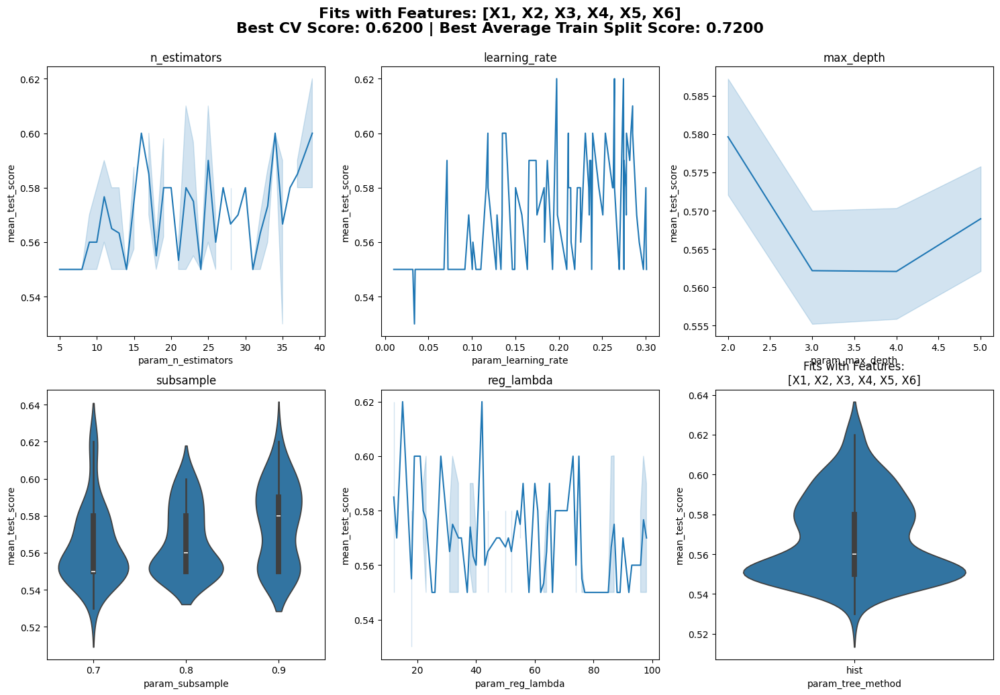

[21:38:42] ======== Monitor (0): HostSketchContainer ========
[21:38:42] AllReduce: 1.8e-05s, 1 calls @ 18us

[21:38:42] MakeCuts: 2.4e-05s, 1 calls @ 24us

[21:38:42] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (100, 6, 600).
[21:38:42] DEBUG: C:\actions-runner\_work\xgboost\xgboost\src\gbm\gbtree.cc:126: Using tree method: 3
[21:38:42] ======== Monitor (0): GBTree ========
[21:38:42] BoostNewTrees: 0.002331s, 23 calls @ 2331us

[21:38:42] CommitModel: 1.7e-05s, 23 calls @ 17us

[21:38:42] ======== Monitor (0): HistUpdater ========
[21:38:42] BuildHistogram: 0.0003s, 23 calls @ 300us

[21:38:42] EvaluateSplits: 0.000371s, 46 calls @ 371us

[21:38:42] InitData: 0.000158s, 23 calls @ 158us

[21:38:42] InitRoot: 0.000529s, 23 calls @ 529us

[21:38:42] LeafPartition: 0.000152s, 23 calls @ 152us

[21:38:42] UpdatePosition: 0.000337s, 46 calls @ 337us

[21:38:42] UpdatePredictionCache: 7.4e-05s, 23 calls @ 74u

e:\dev\workspace\Apziva\Project1\src\utils\tune_hyperparameters.py:297: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_subset, show=False)


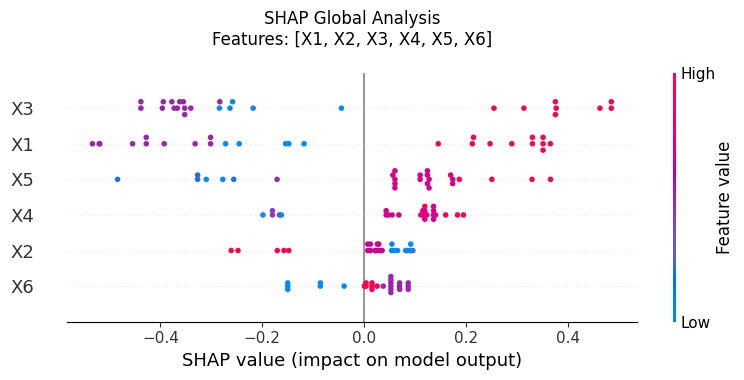

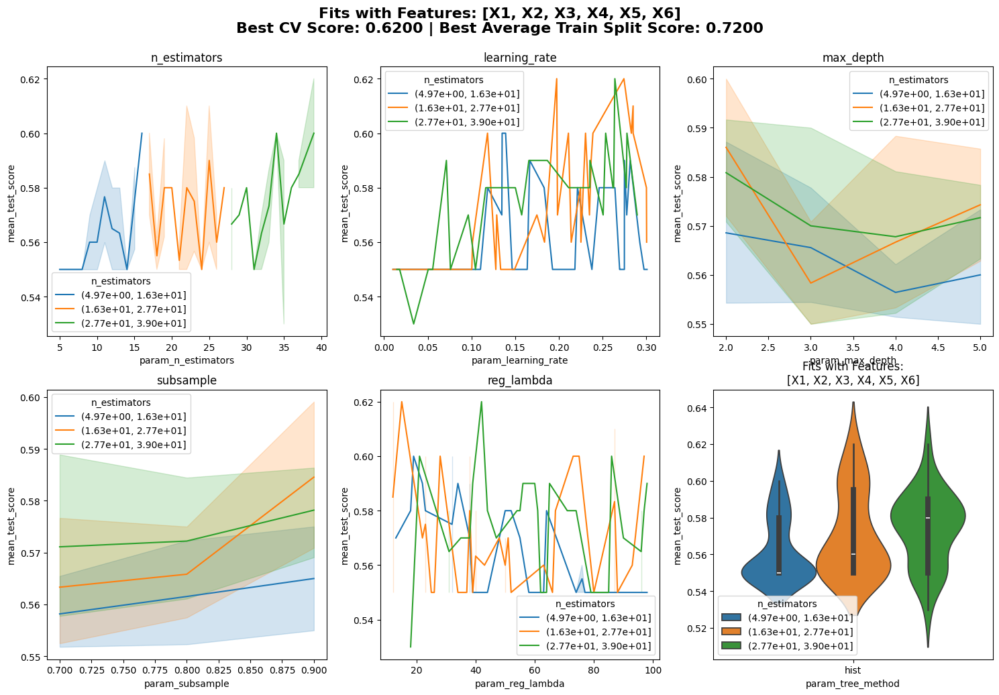

In [12]:
parameter_grid = {
        # Number of boosted trees to fit (also equivalent to number of boosting rounds)
        'n_estimators': randint(5, 40),

        # Step size shrinkage used in updates to prevent overfitting
        'learning_rate': uniform(0.01, .3),

        # Maximum depth of a tree. Increasing this makes the model more complex and likely to overfit
        'max_depth': randint(2,6),

        # Minimum sum of instance weight (hessian) needed in a child
        # 'min_child_weight': uniform(1, 5),

        # Subsample ratio of the training instances (fraction of observations used per tree)
        'subsample': [.7,.8,.9,],

        # Subsample ratio of columns when constructing each tree
        # 'colsample_bytree': [.5,.75,1],

        # Minimum loss reduction required to make a further partition on a leaf node
        # 'gamma': uniform(0, 4),

        # L1 regularization term on weights (higher values make the model more conservative)
        # 'reg_alpha':uniform(0,1),

        # L2 regularization term on weights (higher values make the model more conservative)
        'reg_lambda': randint(10, 100),

        # Maximum number of discrete bins to bucket continuous features
        # 'max_bin': randint(64, 256),

        # Specifies the tree construction algorithm used
        'tree_method': ['hist'],

        # Specifies the type of booster to use
        # 'booster': ['gbtree',]
}
model = xgb.XGBClassifier(random_state = random_state, verbosity = 3,)
categorical_features = ["X1","X2","X3","X4","X5","X6"]

t = ModelTuner(model, filename, "Y", categorical_features, random_state = random_state)

search = t.tune_model(hyperParameterGrid=parameter_grid, n_iter = 100,)
t.feature_permutation(search.best_params_)
t.shap_analysis(search.best_params_)
t.display_parameter_fits(search, parameter_grid, groupby="n_estimators")

Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV 1/5; 1/100] START learning_rate=0.13510660141077221, max_depth=6, n_estimators=13, reg_lambda=29, subsample=0.8, tree_method=hist
[21:38:44] ======== Monitor (0): HostSketchContainer ========
[21:38:44] AllReduce: 9e-06s, 1 calls @ 9us

[21:38:44] MakeCuts: 1.6e-05s, 1 calls @ 16us

[21:38:44] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (80, 2, 160).
[21:38:44] DEBUG: C:\actions-runner\_work\xgboost\xgboost\src\gbm\gbtree.cc:126: Using tree method: 3
[21:38:44] ======== Monitor (0): GBTree ========
[21:38:44] BoostNewTrees: 0.002471s, 13 calls @ 2471us

[21:38:44] CommitModel: 1e-05s, 13 calls @ 10us

[21:38:44] ======== Monitor (0): HistUpdater ========
[21:38:44] BuildHistogram: 0.000625s, 24 calls @ 625us

[21:38:44] EvaluateSplits: 0.000391s, 37 calls @ 391us

[21:38:44] InitData: 0.000148s, 13 calls @ 148us

[21:38:44] InitRoot: 0.000

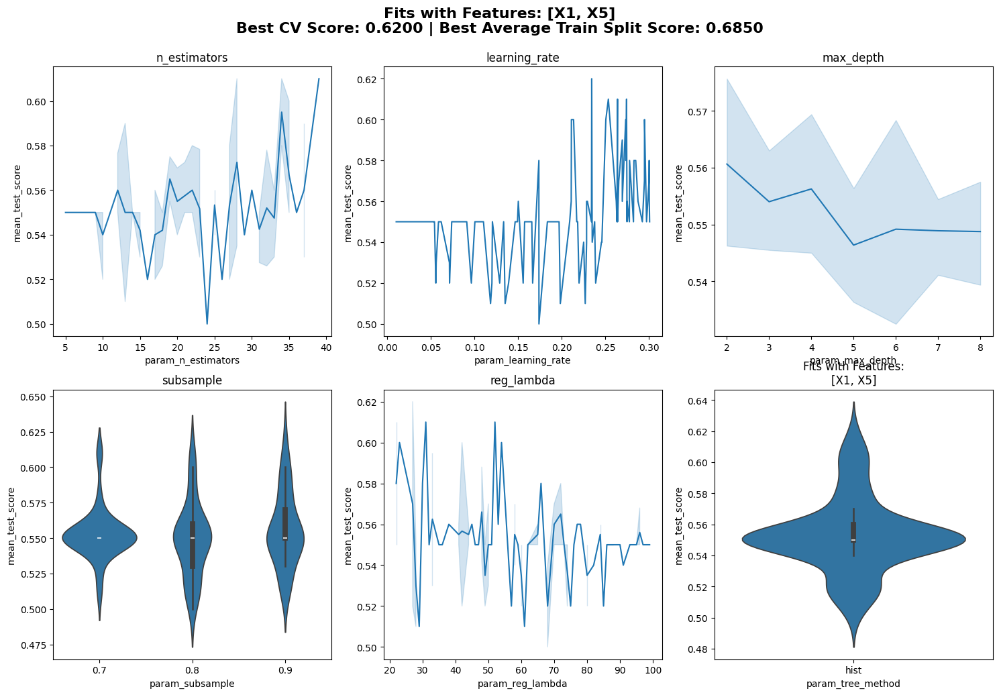

[21:38:59] ======== Monitor (0): HostSketchContainer ========
[21:38:59] AllReduce: 1.8e-05s, 1 calls @ 18us

[21:38:59] MakeCuts: 2.2e-05s, 1 calls @ 22us

[21:38:59] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (100, 2, 200).
[21:38:59] DEBUG: C:\actions-runner\_work\xgboost\xgboost\src\gbm\gbtree.cc:126: Using tree method: 3
[21:38:59] ======== Monitor (0): GBTree ========
[21:38:59] BoostNewTrees: 0.003674s, 28 calls @ 3674us

[21:38:59] CommitModel: 1.6e-05s, 28 calls @ 16us

[21:38:59] ======== Monitor (0): HistUpdater ========
[21:38:59] BuildHistogram: 0.000875s, 69 calls @ 875us

[21:38:59] EvaluateSplits: 0.000685s, 97 calls @ 685us

[21:38:59] InitData: 0.000222s, 28 calls @ 222us

[21:38:59] InitRoot: 0.000584s, 28 calls @ 584us

[21:38:59] LeafPartition: 0.000102s, 28 calls @ 102us

[21:38:59] UpdatePosition: 0.00063s, 71 calls @ 630us

[21:38:59] UpdatePredictionCache: 9.1e-05s, 28 calls @ 91

e:\dev\workspace\Apziva\Project1\src\utils\tune_hyperparameters.py:297: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_subset, show=False)


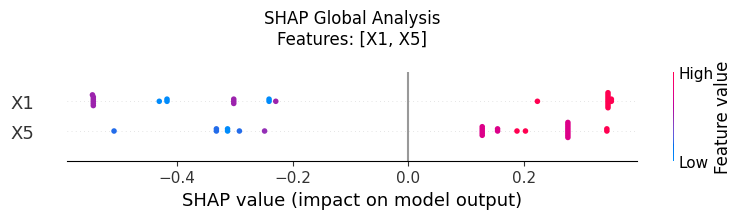

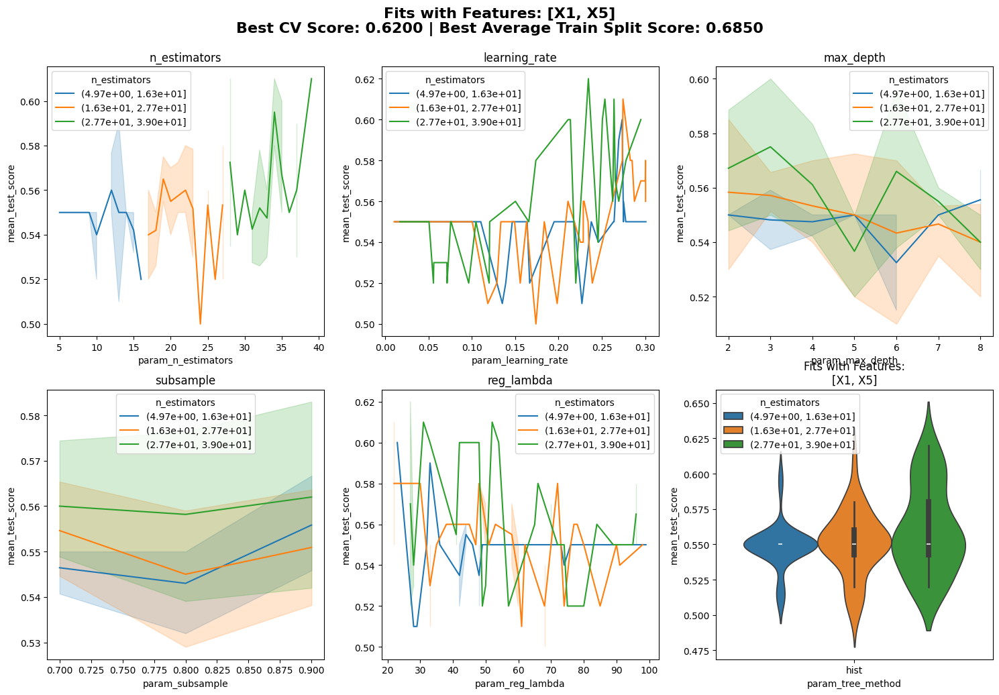

In [13]:
parameter_grid = {
        # Number of boosted trees to fit (also equivalent to number of boosting rounds)
        'n_estimators': randint(5, 40),

        # Step size shrinkage used in updates to prevent overfitting
        'learning_rate': uniform(0.01, .3),

        # Maximum depth of a tree. Increasing this makes the model more complex and likely to overfit
        'max_depth': randint(2,9),

        # Minimum sum of instance weight (hessian) needed in a child
        # 'min_child_weight': uniform(1, 5),

        # Subsample ratio of the training instances (fraction of observations used per tree)
        'subsample': [.7,.8,.9,],

        # Subsample ratio of columns when constructing each tree
        # 'colsample_bytree': [.5,.75,1],

        # Minimum loss reduction required to make a further partition on a leaf node
        # 'gamma': uniform(0, 4),

        # L1 regularization term on weights (higher values make the model more conservative)
        # 'reg_alpha':uniform(0,1),

        # L2 regularization term on weights (higher values make the model more conservative)
        'reg_lambda': randint(20, 100),

        # Maximum number of discrete bins to bucket continuous features
        # 'max_bin': randint(64, 256),

        # Specifies the tree construction algorithm used
        'tree_method': ['hist'],

        # Specifies the type of booster to use
        # 'booster': ['gbtree',]
}
model = xgb.XGBClassifier(random_state = random_state, verbosity = 3,)
categorical_features = ["X1","X5"]

t = ModelTuner(model, filename, "Y", categorical_features, random_state = random_state)

search = t.tune_model(hyperParameterGrid=parameter_grid, n_iter = 100,)
t.feature_permutation(search.best_params_)
t.shap_analysis(search.best_params_)
t.display_parameter_fits(search, parameter_grid, groupby="n_estimators")

In [14]:
t.last_search.best_params_

{'learning_rate': np.float64(0.23444969631395182),
 'max_depth': 4,
 'n_estimators': 28,
 'reg_lambda': 27,
 'subsample': 0.9,
 'tree_method': 'hist'}

In [15]:
t.predict_test_split(t.last_search.best_params_)

[21:39:01] ======== Monitor (0): HostSketchContainer ========
[21:39:01] AllReduce: 1.8e-05s, 1 calls @ 18us

[21:39:01] MakeCuts: 2.5e-05s, 1 calls @ 25us

[21:39:01] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (100, 2, 200).
[21:39:01] DEBUG: C:\actions-runner\_work\xgboost\xgboost\src\gbm\gbtree.cc:126: Using tree method: 3
[21:39:01] ======== Monitor (0): GBTree ========
[21:39:01] BoostNewTrees: 0.026559s, 28 calls @ 26559us

[21:39:01] CommitModel: 2e-05s, 28 calls @ 20us

[21:39:01] ======== Monitor (0): HistUpdater ========
[21:39:01] BuildHistogram: 0.004018s, 69 calls @ 4018us

[21:39:01] EvaluateSplits: 0.007107s, 97 calls @ 7107us

[21:39:01] InitData: 0.000754s, 28 calls @ 754us

[21:39:01] InitRoot: 0.014165s, 28 calls @ 14165us

[21:39:01] LeafPartition: 0.000526s, 28 calls @ 526us

[21:39:01] UpdatePosition: 0.003863s, 71 calls @ 3863us

[21:39:01] UpdatePredictionCache: 0.000298s, 28 call

0.7307692307692307

In [16]:
import pandas as pd
pd.DataFrame(t.last_search.cv_results_).loc[t.last_search.best_index_]

mean_fit_time                                                   0.017911
std_fit_time                                                    0.000698
mean_score_time                                                 0.004956
std_score_time                                                  0.000075
param_learning_rate                                              0.23445
param_max_depth                                                        4
param_n_estimators                                                    28
param_reg_lambda                                                      27
param_subsample                                                      0.9
param_tree_method                                                   hist
params                 {'learning_rate': 0.23444969631395182, 'max_de...
split0_test_score                                                    0.6
split1_test_score                                                   0.65
split2_test_score                                  

In [17]:
t.save_model(filename="../../src/models/saved_models/XGBoost", hyperparams=t.last_search.best_params_, final=True, notes="CV: 0.62 ± 0.074833, trainScore: 0.685 ± 0.024238, testScore1: 0.7307692307692307")

[21:39:01] ======== Monitor (0): HostSketchContainer ========
[21:39:01] AllReduce: 1.8e-05s, 1 calls @ 18us

[21:39:01] MakeCuts: 2.2e-05s, 1 calls @ 22us

[21:39:01] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (126, 2, 252).
[21:39:01] DEBUG: C:\actions-runner\_work\xgboost\xgboost\src\gbm\gbtree.cc:126: Using tree method: 3
[21:39:01] ======== Monitor (0): GBTree ========
[21:39:01] BoostNewTrees: 0.008331s, 28 calls @ 8331us

[21:39:01] CommitModel: 1.9e-05s, 28 calls @ 19us

[21:39:01] ======== Monitor (0): HistUpdater ========
[21:39:01] BuildHistogram: 0.002668s, 78 calls @ 2668us

[21:39:01] EvaluateSplits: 0.001301s, 106 calls @ 1301us

[21:39:01] InitData: 0.000457s, 28 calls @ 457us

[21:39:01] InitRoot: 0.000971s, 28 calls @ 971us

[21:39:01] LeafPartition: 0.000197s, 28 calls @ 197us

[21:39:01] UpdatePosition: 0.001446s, 89 calls @ 1446us

[21:39:01] UpdatePredictionCache: 0.000219s, 28 call